# Notebook 06: Parameter Sensitivity / 参数敏感性分析 (Fig 7)

**对应论文 Figure 7** — 参数敏感性

扫描三个关键参数: c2 (声速平方), drag (Hubble阻尼), steps (演化步数)。
对每组参数计算偏度、峰度和功率谱相关系数。

**Expected key result / 预期关键结果:**
- 近高斯性在宽参数范围内稳健
- r > 0.95 for c2 ∈ [0.2, 0.7]

In [1]:
# ── Imports / 导入 ──
import sys; sys.path.insert(0, '../src')
from dsc_engine import *

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print("Engine loaded / ")

Engine loaded / 


## 1. Helper: single-run metric extraction / 辅助函数: 单次运行指标提取

In [2]:
N_GRID = 256  # 较小Lattice加速扫描 / smaller grid for speed

def run_and_measure(c2_base=0.45, drag=0.01, n_steps=45, seed=42):
    """Run one simulation and return (skewness, kurtosis, spectral_corr)."""
    phi0 = generate_initial_2d(N_GRID, seed=seed)
    phi = evolve_symplectic_2d(phi0, n_steps=n_steps, c2_base=c2_base,
                                c0=10.0, drag=drag)
    phi = apply_silk_damping(phi, k_silk=35.0)
    phi = normalize(phi)
    
    rep = gaussianity_report(phi.ravel())
    k_bins, Dk, _ = compute_power_spectrum(phi)
    Dk_mock = mock_lcdm_spectrum(k_bins)
    mask = (k_bins >= 2) & (k_bins <= 80)
    r = np.corrcoef(smooth(Dk[mask], 5), smooth(Dk_mock[mask], 5))[0, 1]
    return rep['skewness'], rep['kurtosis'], r

print("Helper ready / ")

Helper ready / 


## 2. Parameter scans / 参数扫描

扫描 c2 ∈ [0.1, 0.8], drag ∈ [0, 0.06], steps ∈ [10, 130]

In [3]:
# ── Scan c2 / 扫描声速平方 c2 ──
c2_vals = np.linspace(0.1, 0.8, 15)
c2_skew, c2_kurt, c2_corr = [], [], []
for c2 in c2_vals:
    s, k, r = run_and_measure(c2_base=c2)
    c2_skew.append(s); c2_kurt.append(k); c2_corr.append(r)
print(f"c2 scan done: {len(c2_vals)} points")

# ── Scan drag / 扫描阻尼系数 drag ──
drag_vals = np.linspace(0.0, 0.06, 13)
drag_skew, drag_kurt, drag_corr = [], [], []
for d in drag_vals:
    s, k, r = run_and_measure(drag=d)
    drag_skew.append(s); drag_kurt.append(k); drag_corr.append(r)
print(f"drag scan done: {len(drag_vals)} points")

# ── Scan steps / 扫描演化Steps ──
step_vals = np.arange(10, 131, 10)
step_skew, step_kurt, step_corr = [], [], []
for ns in step_vals:
    s, k, r = run_and_measure(n_steps=int(ns))
    step_skew.append(s); step_kurt.append(k); step_corr.append(r)
print(f"steps scan done: {len(step_vals)} points")

c2 scan done: 15 points


drag scan done: 13 points


steps scan done: 13 points


## 3. Plot 2x3 panels / 绘制 2×3 面板图 (Fig 7)

上排: 高斯性指标 (skewness, kurtosis) vs 参数
下排: 功率谱相关系数 r vs 参数

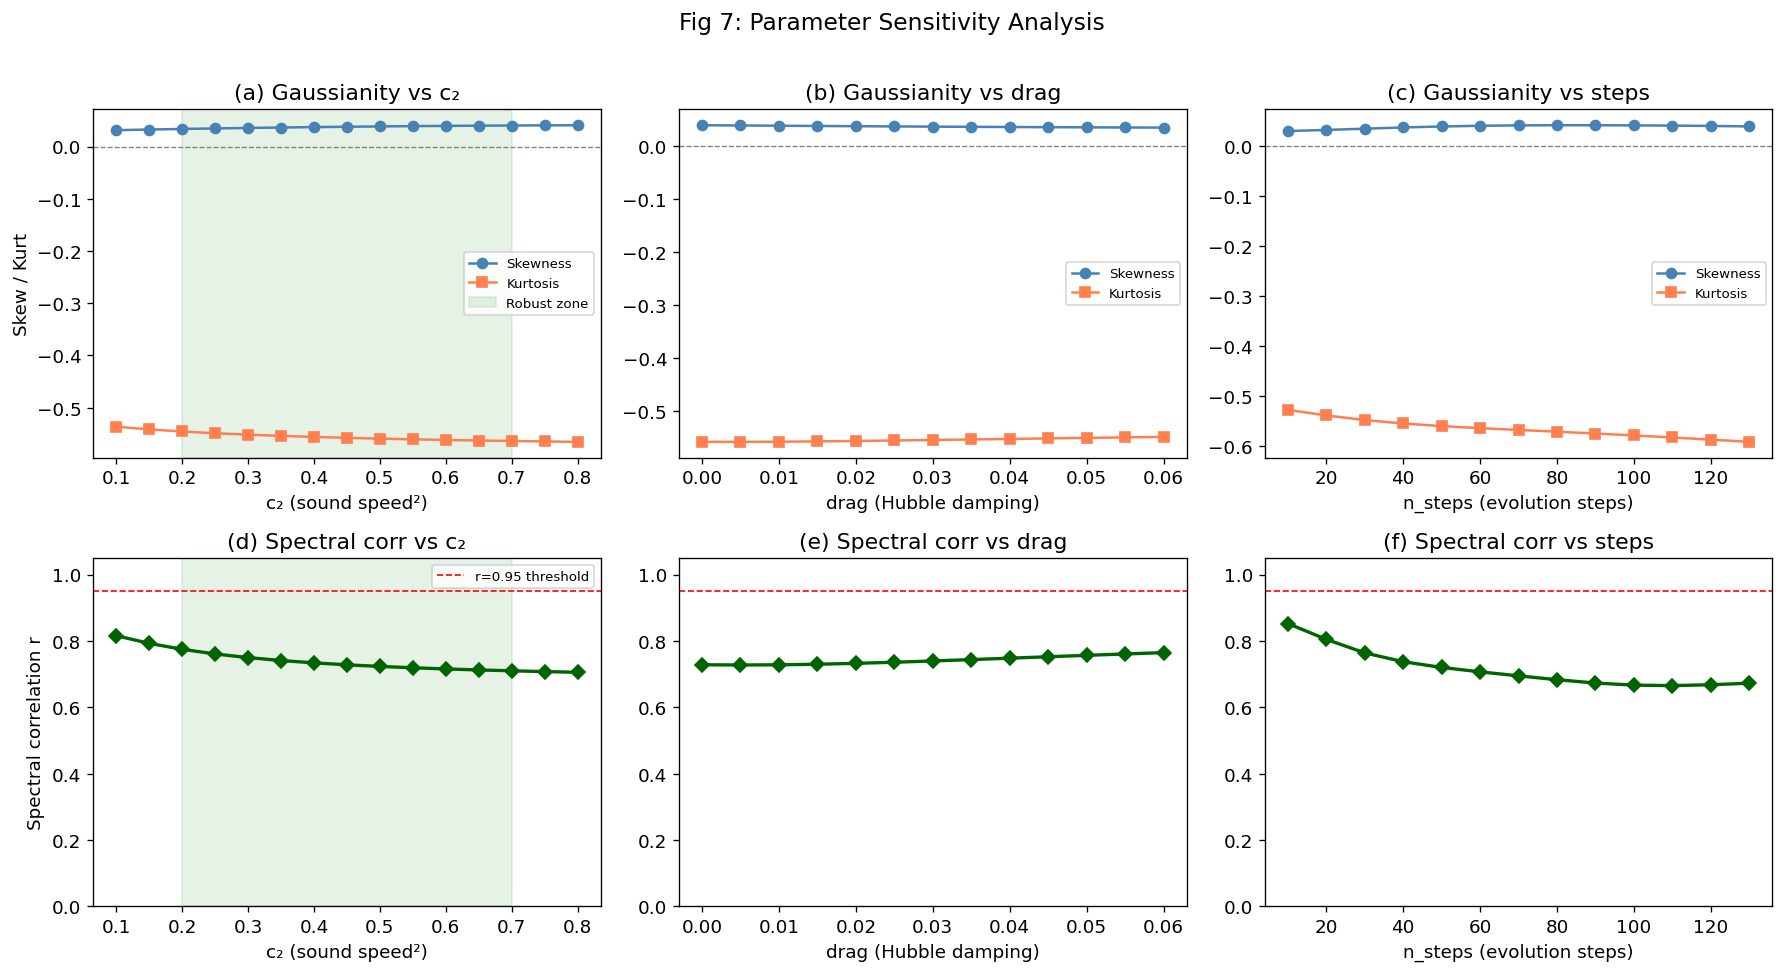

Figure saved to ../figures/fig7_parameter_sensitivity.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ── Top row: Gaussianity / 上排: Gaussianity ──
# (a) vs c2
ax = axes[0, 0]
ax.plot(c2_vals, c2_skew, 'o-', color='steelblue', label='Skewness')
ax.plot(c2_vals, c2_kurt, 's-', color='coral', label='Kurtosis')
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.axvspan(0.2, 0.7, alpha=0.1, color='green', label='Robust zone')
ax.set_xlabel('c₂ (sound speed²)')
ax.set_ylabel('Skew / Kurt')
ax.set_title('(a) Gaussianity vs c₂')
ax.legend(fontsize=8)

# (b) vs drag
ax = axes[0, 1]
ax.plot(drag_vals, drag_skew, 'o-', color='steelblue', label='Skewness')
ax.plot(drag_vals, drag_kurt, 's-', color='coral', label='Kurtosis')
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_xlabel('drag (Hubble damping)')
ax.set_title('(b) Gaussianity vs drag')
ax.legend(fontsize=8)

# (c) vs steps
ax = axes[0, 2]
ax.plot(step_vals, step_skew, 'o-', color='steelblue', label='Skewness')
ax.plot(step_vals, step_kurt, 's-', color='coral', label='Kurtosis')
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_xlabel('n_steps (evolution steps)')
ax.set_title('(c) Gaussianity vs steps')
ax.legend(fontsize=8)

# ── Bottom row: Spectral correlation / 下排: Power Spectrum相关 ──
# (d) vs c2
ax = axes[1, 0]
ax.plot(c2_vals, c2_corr, 'D-', color='darkgreen', lw=2)
ax.axhline(0.95, color='red', ls='--', lw=1, label='r=0.95 threshold')
ax.axvspan(0.2, 0.7, alpha=0.1, color='green')
ax.set_xlabel('c₂ (sound speed²)')
ax.set_ylabel('Spectral correlation r')
ax.set_title('(d) Spectral corr vs c₂')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)

# (e) vs drag
ax = axes[1, 1]
ax.plot(drag_vals, drag_corr, 'D-', color='darkgreen', lw=2)
ax.axhline(0.95, color='red', ls='--', lw=1)
ax.set_xlabel('drag (Hubble damping)')
ax.set_title('(e) Spectral corr vs drag')
ax.set_ylim(0, 1.05)

# (f) vs steps
ax = axes[1, 2]
ax.plot(step_vals, step_corr, 'D-', color='darkgreen', lw=2)
ax.axhline(0.95, color='red', ls='--', lw=1)
ax.set_xlabel('n_steps (evolution steps)')
ax.set_title('(f) Spectral corr vs steps')
ax.set_ylim(0, 1.05)

plt.suptitle('Fig 7: Parameter Sensitivity Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/fig7_parameter_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to ../figures/fig7_parameter_sensitivity.png")